<a href="https://colab.research.google.com/github/Dickmanns/ai_project_1/blob/main/04_model_free_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip3 install mushroom_rl
# !pip3 install pynput
# from IPython.display import clear_output
# clear_output()

# Online Practical Sessions - Model-free prediction (TD evaluation, MC):
We are going to implement three methods, every-visit MC, TD(0) and TD($\lambda$) to evaluate a policy in a model-free way.

In [ ]:
import numpy as np

from mushroom_rl.environments import FiniteMDP
from mushroom_rl.environments.generators import *

### Let's recall the code presented in the previous Online Practical Session (we are going to evaluate the policy that you found using policy iteration)

In [ ]:
##### From the previous Practical Session #####
# Define the grid world
grid=np.array([['.', '.', '.', '.', '.'],
     ['.', '.', '.', '.', '.'],
     ['#', '#', '#', '#', '.'],
     ['.', '.', '.', '.', '.'],
     ['G', '*', '*', '.', '.']
     ])
print(grid)

# change in coordinates for each action
# Right, Down, Left, Up
directions = [[0, 1], [1, 0], [0, -1], [-1, 0]]

# Define the transition probability matrix
def compute_probabilities(grid_map, cell_list, prob):
    """
    Compute the transition probability matrix.

    Args:
        grid_map (list): list containing the grid structure;
        cell_list (list): list of non-wall cells;
        prob (float): probability of success of an action.

    Returns:
        The transition probability matrix;

    """
    g = np.array(grid_map)
    c = np.array(cell_list)
    n_states = len(cell_list)
    p = np.zeros((n_states, 4, n_states))

    for i in range(len(c)):
        state = c[i]

        if g[tuple(state)] in ['.', 'S']:
            for a in range(len(directions)):
                new_state = state + directions[a]
                j = np.where((c == new_state).all(axis=1))[0]
                if j.size > 0:
                    assert j.size == 1

                    p[i, a, i] = 1. - prob
                    p[i, a, j] = prob
                else:
                    p[i, a, i] = 1.

    return p

# Define the reward matrix
def compute_reward(grid_map, cell_list):
    """
    Compute the reward matrix.

    Args:
        grid_map (list): list containing the grid structure;
        cell_list (list): list of non-wall cells;
        pos_rew (float): reward obtained in goal states;
        neg_rew (float): reward obtained in "hole" states;

    Returns:
        The reward matrix.

    """
    g = np.array(grid_map)
    c = np.array(cell_list)
    n_states = len(c)
    r = np.zeros((n_states, 4, n_states))

    def give_reward(t, rew):
        for x in np.argwhere(g == t):
            j = np.where((c == x).all(axis=1))[0]

            for a in range(len(directions)):
                prev_state = x - directions[a]
                if prev_state.tolist() in c.tolist():
                    i = np.where((c == prev_state).all(axis=1))[0]
                    r[i, a, j] = rew

    give_reward('G', 1.)
    give_reward('*', -1.)
    give_reward('.', -.01)

    return r

# Define the initial state distribution
def compute_mu(grid_map, cell_list):
    """
    Compute the initial states distribution.

    Args:
        grid_map (list): list containing the grid structure;
        cell_list (list): list of non-wall cells.

    Returns:
        The initial states distribution.

    """
    g = np.array(grid_map)
    c = np.array(cell_list)
    n_states = len(c)
    mu = np.zeros(n_states)

    for idx, (i, j)  in enumerate(cell_list):
        mu[idx] = 1. if g[i][j] == '.' else 0.

    mu = mu / mu.sum()
    mu = mu.flatten()
    return mu

def policy_iteration(prob, reward, gamma):
    """
    Policy iteration algorithm to solve a dynamic programming problem.
    Args:
        prob (np.ndarray): transition probability matrix;
        reward (np.ndarray): reward matrix;
        gamma (float): discount factor.
    Returns:
        The optimal value of each state and the optimal policy.
    """
    # get the number of states and actions
    n_states = prob.shape[0]
    n_actions = prob.shape[1]
    # initialize the policy and value matrices
    policy = np.zeros(n_states, dtype=int)
    value = np.zeros(n_states)
    # iterate until the policy and value stop changing
    changed = True
    while changed:
      # Policy Evaluation
      # I
      i = np.eye(n_states)
      # array to collect P^{pi} and R^{pi} over next states
      p_pi = np.zeros((n_states, n_states))
      r_pi = np.zeros(n_states)
      # iterate over next states
      for state in range(n_states):
        # get the action form the policy
        action = policy[state]
        # get P_s^{pi} and R_s^{pi}
        p_pi_s = prob[state, action, :]
        r_pi_s = reward[state, action, :]
        # update P^{pi} with P_s^{pi}
        p_pi[state, :] = p_pi_s.T
        # update R^{pi} with P_s^{pi}^T . R_s^{pi}
        r_pi[state] = p_pi_s.T.dot(r_pi_s)
      # solve to get V : V (I-\gamma P^{pi}) = R^{pi}
      value = np.linalg.solve(i - gamma * p_pi, r_pi)
      # Policy iteration
      changed = False
      for state in range(n_states):
        # get the value of the state
        vmax = value[state]
        # iterate over all actions
        for action in range(n_actions):
          # if the action is different from the output of the policy thus the policy is not stable yet
          if action != policy[state]:
            # get P_s,a and R_s,a
            p_sa = prob[state, action]
            r_sa = reward[state, action]
            # update the value P_s,a^T . (R_s,a + \gamma * V)
            va = p_sa.T.dot(r_sa + gamma * value)
            # if the value is bigger than the old value and not close (small difference)
            # get the argmax action
            if va > vmax and not np.isclose(va, vmax):
              # update the policy
              policy[state] = action
              # update the max value
              vmax = va
              # update the changed flag
              changed = True
    return value, policy

# walls are not states
rows, cols = np.where(grid!='#')
cell_list = [[r, c] for r, c in zip(rows, cols)]

# compute the transition probabilities, rewards and initial state distribution
p = compute_probabilities(grid, cell_list, prob=0.95)
r = compute_reward(grid, cell_list)
mu = compute_mu(grid, cell_list)
env = FiniteMDP(p, r, mu, gamma=0.99, horizon=10)

_, pi = policy_iteration(env.p, env.r, gamma=0.99)

#########################################################################################

### Let's now evaluate the policy $pi$ in a model free way using Monte Carlo, TD(0) and TD($\lambda$) methods

**Every-visit Monte Carlo Policy Evaluation:**


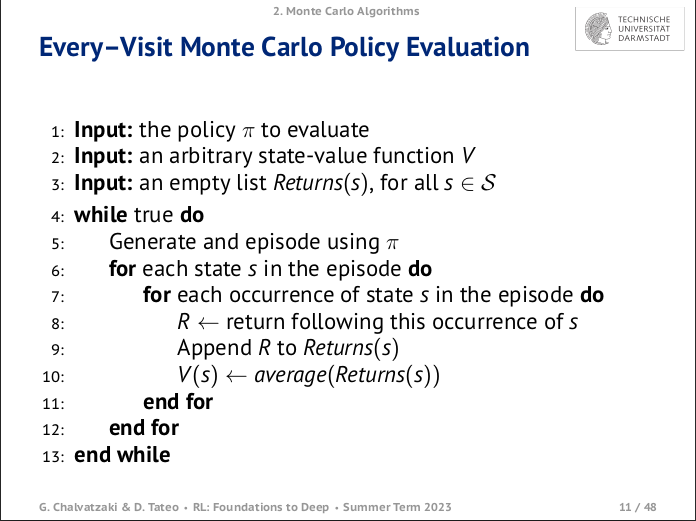

In [ ]:
def evaluate_policy_mc(policy, V, returns_list, env, n_episodes=10):
    for _ in range(n_episodes):
        # Initialize state, done and episode list (to contain state and reward tuples)
        state = env.reset()
        done = False
        episode = []

        # Generate an episode following the policy
        while not done:
            action = ### TODO ###
            next_state, reward, done, _ = ### TODO ###
            # Store state and reward tuple in episode
            ### TODO ###
            state = next_state
            if done:
                break

        G = 0
        for i, (state, reward) in enumerate(episode[::-1]):
            # Calculare return following this occurrence of state
            G = ### TODO ###
            # Add the return to the list of returns of the state
            ### TODO ###
            # Update the value function as the mean of the returns of the state
            V[state[0]] = ### TODO ###

    return V

**TD(0) Policy Evaluation:**


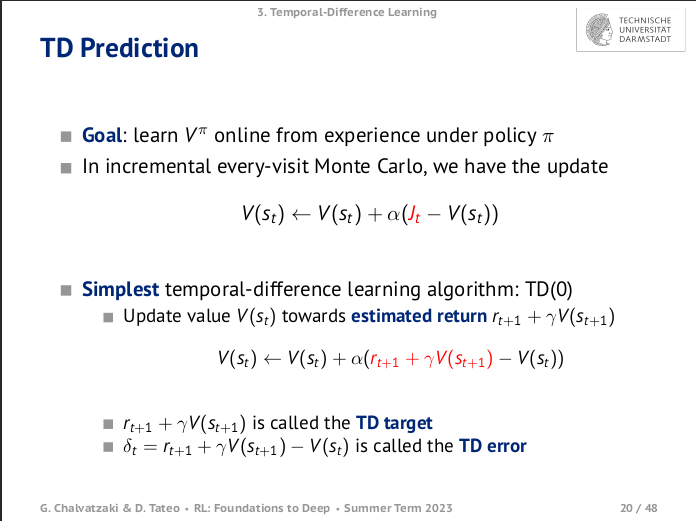

In [ ]:
def evaluate_policy_td(policy, V, env, alpha=0.1, n_episodes=10):
    for _ in range(n_episodes):
        # Initialize state and done
        state = env.reset()
        done = False

        # Generate an episode following the policy
        while not done:
            action = ### TODO ###
            next_state, reward, done, _ = ### TODO ###
            # Compute the TD target as r + gamma * V(s')
            td_target = ### TODO ###
            # Update the value function using the TD error
            V[state] = ### TODO ###
            state = next_state
            if done:
                break

    return V

**TD($\lambda$) Policy Evaluation:**


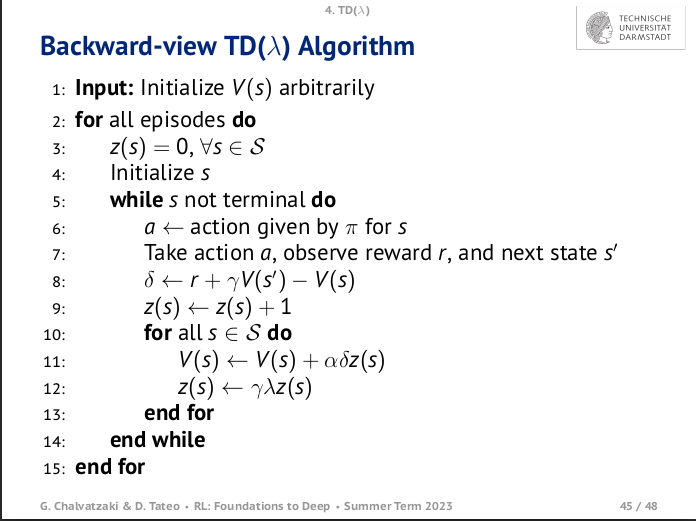

In [ ]:
def evaluate_policy_td_lambda(policy, V, env, alpha=0.1, lmbda=0.5, n_episodes=10):
    n_states = env.p.shape[0]
    eligibility_trace = np.zeros(n_states)

    for _ in range(n_episodes):
        # Initialize state, done and eligibility trace
        eligibility_trace = ### TODO ###
        state = env.reset()
        done = False

        # Generate an episode following the policy
        while not done:
            action = ### TODO ###
            next_state, reward, done, _ = ### TODO ###
            # Compute the TD target as r + gamma * V(s')
            td_target = ### TODO ###
            # Compute the TD error
            td_error = ### TODO ###
            # Update the eligibility trace
            eligibility_trace[state] += ### TODO ###

            for s in range(n_states):
                # Update the value function using the TD error and the eligibility trace
                V[s] = ### TODO ###
                # Update the eligibility trace using the decay factor
                eligibility_trace[s] = ### TODO ###

            if done:
                break

            state = next_state

    return V

Let's define a policy (use the one obtained in the previous OPS) and evaluate it using the implemented strategies

In [ ]:
# Define a policy (use the one obtained in the previous PS)
policy = pi

# Initialize the value function
V = np.zeros(env.p.shape[0])
V_MC_init = np.copy(V)
V_TD_init = np.copy(V)
V_TD_lambda_init = np.copy(V)

# Evaluate the policy using Monte Carlo
# Initialize the list of returns(s) for all states
returns_list = [[] for _ in range(env.p.shape[0])]
np.random.seed(0)
V_MC = evaluate_policy_mc(policy, V_MC_init, returns_list, env, n_episodes=1000)

# Evaluate the policy using TD
np.random.seed(0)
V_TD = evaluate_policy_td(policy, V_TD_init, env, n_episodes=1000)

# Evaluate the policy using TD(\lambda)
np.random.seed(0)
V_TD_lambda = evaluate_policy_td_lambda(policy, V_TD_lambda_init, env, lmbda=0, n_episodes=1000)
print('Sanity check: TD=TD(lambda=0)', V_TD==V_TD_lambda)

### **Let's now plot the value function of the evaluated policy computed with the three methods**

In [ ]:
import matplotlib.pyplot as plt

def visualize_value_matrices(V, H, W, cell_list, label):
  """
  This function visualizes the value matrices.
  Args:
      V: value matrix when
  """
  fig, ax = plt.subplots(1,1, figsize=(10, 5))
  # reshape the value matrices
  V_ = np.zeros((H,W))
  #plt.imshow(V, cmap='jet')
  plt.title(label)
  # write the values in the cells
  for idx, (i, j) in enumerate(cell_list):
      V_[i][j] = V[idx]
      plt.text(j, i, round(V[idx], 2), ha="center", va="center", color="w")
  plt.imshow(V_, cmap='jet')
  plt.show()
  #fig.savefig(label + '.png')

In [ ]:
rows, cols = np.where(grid!='#')
cell_list = [[r, c] for r, c in zip(rows, cols)]

In [ ]:
visualize_value_matrices(V_MC, grid.shape[0], grid.shape[1], cell_list, 'MC')

In [ ]:
visualize_value_matrices(V_TD, grid.shape[0], grid.shape[1], cell_list, 'TD(0)')

In [ ]:
visualize_value_matrices(V_TD_lambda, grid.shape[0], grid.shape[1], cell_list, 'TD(lambda=0)')